# Comprehensive Analysis of Diabetes Medication Regimens & Hospital Stay Outcomes

This notebook explores historical patient records to uncover patterns in diabetes medication prescriptions and evaluates how different treatment regimens impact a patient's **Length of Stay (LOS)** in the hospital. 

### Workflow Overview:
1. **Data Ingestion & Cleaning:** Identify active diabetic medications per patient.
2. **Market Basket Analysis:** Apply the **Apriori Algorithm** to look for common medication combinations (co-prescriptions).
3. **Statistical Modeling (ANOVA & Tukey HSD):** Evaluate if different treatment regimens lead to statistically significant differences in hospital stay durations.
4. **Data Visualization:** Profile the top 10 most common medication regimens against average hospitalization days.

In [1]:
import pandas as pd
import numpy as np

!pip install mlxtend
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

!pip install scipy
import scipy.stats as stats

!pip install statsmodels
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import seaborn as sns
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=12576) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


/opt/anaconda3/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=12576) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


In [2]:
# Load the preprocessed clinical dataset
df = pd.read_csv('processed.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53298 entries, 0 to 53297
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              53298 non-null  int64 
 1   patient_nbr               53298 non-null  int64 
 2   race                      53298 non-null  object
 3   gender                    53298 non-null  object
 4   age                       53298 non-null  object
 5   admission_type_id         53298 non-null  int64 
 6   discharge_disposition_id  53298 non-null  int64 
 7   admission_source_id       53298 non-null  int64 
 8   time_in_hospital          53298 non-null  int64 
 9   medical_specialty         53298 non-null  object
 10  num_lab_procedures        53298 non-null  int64 
 11  num_procedures            53298 non-null  int64 
 12  num_medications           53298 non-null  int64 
 13  number_outpatient         53298 non-null  int64 
 14  number_emergency      

## Feature Engineering: Extracting Treatment Regimens

To find co-prescription rules, we must convert the wide tabular medication features into a consolidated transactional list format containing only actively prescribed features (`'Up'`, `'Down'`, or `'Steady'`).

In [4]:
# Full list of documented diabetes medications in the dataset
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 
              'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol','troglitazone', 
              'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 
              'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

# Count how many records have an active prescription (any status other than 'No') for each drug
for med in med_cols:
    count = (df[med] != 'No').sum()
    print (med, count)

metformin 14902
repaglinide 917
nateglinide 491
chlorpropamide 71
glimepiride 3697
acetohexamide 1
glipizide 9009
glyburide 7775
tolbutamide 17
pioglitazone 5265
rosiglitazone 4658
acarbose 200
miglitol 20
troglitazone 3
tolazamide 30
examide 0
citoglipton 0
insulin 35718
glyburide-metformin 496
glipizide-metformin 7
glimepiride-pioglitazone 0
metformin-rosiglitazone 2
metformin-pioglitazone 1


In [5]:
# Filtered down to key core medications (over 30 count) for transactional processing
core_meds = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 
             'pioglitazone', 'rosiglitazone', 'acarbose', 'insulin', 'glyburide-metformin']

def get_active_meds(row):
    """
    Checks each core medication column to see if it's currently being actively 
    titrated or maintained for the patient.
    """
    active_meds = [meds for meds in core_meds if row[meds] in ['Up', 'Down', 'Steady']]
    if len(active_meds) > 0:
        return active_meds
    else:
        return ['No_Diabetes_Med']
        
# Isolate transactional array pairs per patient encounter
df['medication_list'] = df.apply(get_active_meds, axis = 1)
df['medication_list'].head()

0               [insulin]
1             [glipizide]
2               [insulin]
3    [glipizide, insulin]
4               [insulin]
Name: medication_list, dtype: object

In [6]:
# Instantiate and fit the transactional encoder to shape a boolean matrix
te = TransactionEncoder()
te_array = te.fit(df['medication_list']).transform(df['medication_list'])
df_onehot = pd.DataFrame(te_array, columns = te.columns_)

df_onehot.head()

,No_Diabetes_Med,acarbose,chlorpropamide,glimepiride,glipizide,glyburide,glyburide-metformin,insulin,metformin,nateglinide,pioglitazone,repaglinide,rosiglitazone
0,False,False,False,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,True,False,False,True,False,False,False,False,False
4,False,False,False,False,False,False,False,True,False,False,False,False,False


## Market Basket Analysis: Uncovering Frequent Co-Prescriptions

We use the **Apriori Algorithm** to discover frequent itemsets. First, we will run a hyperparameter sweep over different minimum support thresholds (`min_support`) to find an ideal volume of meaningful rules.

In [7]:
# Test multiple support thresholds to balance itemset depth against noise
for s in [0.02, 0.01, 0.005, 0.002, 0.001]:
    fi = apriori(df_onehot, min_support = s, use_colnames = True)
    print(s, len(fi))

0.02 19
0.01 28
0.005 43
0.002 57
0.001 73


The hyperparameter sweep evaluated the rule yield across a range of minimum support values ($s \in [0.001, 0.02]$). 
* At high support levels ($2\%$), the algorithm captures only the absolute most ubiquitous single medications, missing out on multi-drug interaction patterns.
* At lower support levels ($0.1\%$), the itemset yield explodes, which risks capturing rare, statistically noisy combinations that lack clinical significance.
* **Selection:** A minimum support threshold of **$0.5\%$ ($0.005$)** was selected as the optimal balance. It maintains structural significance while capturing complex multi-drug regimens with sufficient sample sizes.

In [8]:
# Compute frequent itemsets at our chosen sweet spot (support >= 0.5%)
frequent_itemsets = apriori(df_onehot, min_support = 0.005, use_colnames = True)
frequent_itemsets

,support,itemsets
0,0.069365,(glimepiride)
1,0.169031,(glipizide)
2,0.145878,(glyburide)
3,0.009306,(glyburide-metformin)
4,0.670156,(insulin)
5,0.279598,(metformin)
6,0.009212,(nateglinide)
7,0.098784,(pioglitazone)
8,0.017205,(repaglinide)
9,0.087395,(rosiglitazone)


In [9]:
# Extract comprehensive association rules across the whole itemset matrix
rules = association_rules(frequent_itemsets, metric = 'support', min_threshold = 0)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(insulin),(glimepiride),0.670156,0.069365,0.036324,0.054202,0.781411,1.0,-0.010161,0.983969,-0.458900,0.051656,-0.016292,0.288935
1,(glimepiride),(insulin),0.069365,0.670156,0.036324,0.523668,0.781411,1.0,-0.010161,0.692465,-0.231116,0.051656,-0.444116,0.288935
2,(glimepiride),(metformin),0.069365,0.279598,0.019588,0.282391,1.009991,1.0,0.000194,1.003893,0.010629,0.059470,0.003878,0.176224
3,(metformin),(glimepiride),0.279598,0.069365,0.019588,0.070058,1.009991,1.0,0.000194,1.000745,0.013731,0.059470,0.000745,0.176224
4,(glimepiride),(pioglitazone),0.069365,0.098784,0.008987,0.129565,1.311592,1.0,0.002135,1.035362,0.255275,0.056466,0.034154,0.110271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,"(insulin, rosiglitazone)",(metformin),0.046231,0.279598,0.016417,0.355114,1.270088,1.0,0.003491,1.117100,0.222960,0.053059,0.104825,0.206915
118,"(rosiglitazone, metformin)",(insulin),0.031239,0.670156,0.016417,0.525526,0.784183,1.0,-0.004518,0.695177,-0.221236,0.023967,-0.438484,0.275011
119,(insulin),"(rosiglitazone, metformin)",0.670156,0.031239,0.016417,0.024497,0.784183,1.0,-0.004518,0.993089,-0.454854,0.023967,-0.006959,0.275011
120,(metformin),"(insulin, rosiglitazone)",0.279598,0.046231,0.016417,0.058717,1.270088,1.0,0.003491,1.013265,0.295186,0.053059,0.013092,0.206915


In [10]:
# Filter for strong positive associations (Lift > 1) and order by operational Confidence
rules = rules[(rules['lift'] > 1)].sort_values(by = 'confidence', ascending = False)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
105,"(glyburide, rosiglitazone)",(metformin),0.012984,0.279598,0.006135,0.472543,1.690083,1.0,0.002505,1.365804,0.413684,0.021419,0.267830,0.247243
100,"(glyburide, pioglitazone)",(metformin),0.013434,0.279598,0.005779,0.430168,1.538523,1.0,0.002023,1.264235,0.354792,0.020118,0.209008,0.225418
80,"(insulin, glyburide)",(metformin),0.060546,0.279598,0.024035,0.396963,1.419765,1.0,0.007106,1.194624,0.314713,0.076033,0.162916,0.241462
74,"(glipizide, rosiglitazone)",(metformin),0.015460,0.279598,0.005966,0.385922,1.380277,1.0,0.001644,1.173145,0.279834,0.020639,0.147591,0.203631
18,(glyburide),(metformin),0.145878,0.279598,0.055574,0.380965,1.362545,1.0,0.014787,1.163750,0.311524,0.150241,0.140709,0.289865
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,(glipizide),"(rosiglitazone, metformin)",0.169031,0.031239,0.005966,0.035298,1.129919,1.0,0.000686,1.004207,0.138369,0.030707,0.004189,0.113145
72,(metformin),"(glipizide, pioglitazone)",0.279598,0.017881,0.006154,0.022010,1.230970,1.0,0.001155,1.004223,0.260455,0.021124,0.004205,0.183093
108,(metformin),"(glyburide, rosiglitazone)",0.279598,0.012984,0.006135,0.021943,1.690083,1.0,0.002505,1.009161,0.566785,0.021419,0.009078,0.247243
79,(metformin),"(glipizide, rosiglitazone)",0.279598,0.015460,0.005966,0.021339,1.380277,1.0,0.001644,1.006007,0.382436,0.020639,0.005971,0.203631


The raw `association_rules` output was filtered using strict statistical and operational constraints to isolate high-value clinical combinations:

$$\text{Lift} > 1 \quad \text{and} \quad \text{Sorted by } \text{Confidence} \ (\downarrow)$$

* **Support ($\ge 0.005$):** Guarantees that the rule applies to a meaningful minimum percentage of the entire patient cohort.
* **Confidence:** Measures the operational reliability of the rule. If a patient takes the antecedent medication(s), Confidence tells us the exact probability ($0\%$ to $100\%$) that they are also taking the consequent medication.
* **Lift ($> 1$):** Crucially proves that the occurrence of the antecedent and consequent are mathematically dependent. A Lift greater than 1 establishes a true co-prescription pattern rather than a random coincidence of two independently popular drugs.

Next, we will normalize these co-prescription patterns into standardized patient **regimens** and run comparative variance testing (ANOVA and Tukey's HSD) to check how these specific combinations directly influence hospital **Length of Stay (LOS)**.

## Statistical Profiling: Impact of Medication Regimens on Hospital Stay ($LOS$)

Next, we evaluate if different clinical treatment combinations dictate significantly different operational outcomes, specifically tracking `time_in_hospital`.

In [11]:
# Flag 30-day readmissions based on clinical classification windows
df['readmitted_30days'] = np.where(df['readmitted'] == '<30', 'True', 'False')

In [12]:
# Normalize medication list order into flat text identifiers representing unique patient 'regimens'
df['regiment'] = df['medication_list'].apply(lambda x: ('+').join(sorted(x)))

To perform a rigorous statistical comparison, the transactional medication lists are flattened and alphabetized into standardized textual strings (e.g., `glipizide + insulin`). This creates a categorical feature representing each patient's exact **treatment regimen**.

In [13]:
# Review the overall prescription volume distribution across unique regimens
df['regiment'].value_counts()

regiment
insulin                                      19358
metformin                                     3387
insulin+metformin                             3073
glipizide                                     2725
glyburide                                     2387
                                             ...  
chlorpropamide+glipizide                         1
acarbose+metformin+pioglitazone                  1
glyburide-metformin+insulin+nateglinide          1
chlorpropamide+metformin+pioglitazone            1
glimepiride+glipizide+glyburide+metformin        1
Name: count, Length: 277, dtype: int64

In [14]:
# Extract the 10 most frequently prescribed regimens for statistical sample power
top_regiments = df['regiment'].value_counts().head(10).index
top_regiments

Index(['insulin', 'metformin', 'insulin+metformin', 'glipizide', 'glyburide',
       'glipizide+insulin', 'glyburide+insulin', 'glyburide+metformin',
       'insulin+pioglitazone', 'glimepiride'],
      dtype='object', name='regiment')

Next, we apply a **One-Way Analysis of Variance (ANOVA)** to test whether the mean hospital stay differs across these ten distinct treatment groups.

* **Null Hypothesis ($H_0$):** The population mean length of stay is identical across all top 10 medication regimens.
  $$\mu_{1} = \mu_{2} = \mu_{3} = \dots = \mu_{10}$$
* **Alternative Hypothesis ($H_1$):** At least one medication regimen has a population mean length of stay that is statistically different from the others.

By running the one-way ANOVA, we assume:
1. **Independence:** Each patient encounter represents an independent event.
2. **Normality:** The distribution of the residuals of the dependent variable (`time_in_hospital`) is approximately normally distributed within each group.
3. **Homoscedasticity:** The variances of the lengths of stay are roughly equal across all treatment cohorts.

In [15]:
# Group length of stay metrics for each of our top 10 treatment classes
groups = []
for r in top_regiments:
    time = df[df['regiment'] == r]['time_in_hospital'].values
    groups.append(time)

# Execute One-way Analysis of Variance (ANOVA) test
f_stats, p_value = stats.f_oneway(*groups)
print(f"ANOVA Result: F-Statistic = {f_stats}, p-value = {p_value}")

ANOVA Result: F-Statistic = 36.773621693353405, p-value = 1.3740307068260156e-65


A one-way ANOVA revealed a statistically significant difference in mean hospital stay across medication regimens, F = 36.77, p < 0.001. This suggests that hospitalization duration varies significantly among different treatment regimens.

Since ANOVA yields a significant $p$-value ($p < 0.05$), we will reject $H_0$ and proceed to **Tukey's Honestly Significant Difference (HSD)** post-hoc test to pinpoint exactly which pairs of regimens differ.

In [16]:
# Isolate a sub-dataframe containing only the top 10 medication regimen populations
df_top_regiment = df[df['regiment'].isin(top_regiments)]
df_top_regiment

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,medication_list,readmitted_30days,regiment
0,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,No,No,No,No,Ch,Yes,>30,[insulin],False,insulin
1,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,Yes,NO,[glipizide],False,glipizide
2,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,No,No,No,No,Ch,Yes,NO,[insulin],False,insulin
3,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,No,No,No,No,Ch,Yes,NO,"[glipizide, insulin]",False,glipizide+insulin
4,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,Unknown,...,No,No,No,No,No,Yes,>30,[insulin],False,insulin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53293,443841992,184875899,Other,Male,[40-50),1,1,7,13,Unknown,...,No,No,No,No,Ch,Yes,NO,"[metformin, insulin]",False,insulin+metformin
53294,443842016,183087545,Caucasian,Female,[70-80),1,1,7,9,Unknown,...,No,No,No,No,Ch,Yes,>30,"[glyburide, insulin]",False,glyburide+insulin
53295,443842022,188574944,Other,Female,[40-50),1,1,7,14,Unknown,...,No,No,No,No,Ch,Yes,>30,"[glipizide, insulin]",False,glipizide+insulin
53296,443842070,140199494,Other,Female,[60-70),1,1,7,2,Unknown,...,No,No,No,No,No,Yes,>30,[insulin],False,insulin


In [17]:
# Perform Tukey's Honestly Significant Difference post-hoc testing 
# to evaluate pairwise group variances
tukey = pairwise_tukeyhsd(
    endog = df_top_regiment['time_in_hospital'],
    groups = df_top_regiment['regiment'],
    alpha = 0.05
)
print(tukey.summary())

              Multiple Comparison of Means - Tukey HSD, FWER=0.05               
       group1               group2        meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------------
         glimepiride            glipizide  -0.0724 0.9997 -0.4183  0.2735  False
         glimepiride    glipizide+insulin   0.7313    0.0  0.3769  1.0856   True
         glimepiride            glyburide   0.2171 0.6353 -0.1353  0.5695  False
         glimepiride    glyburide+insulin   0.7558    0.0  0.3737  1.1378   True
         glimepiride  glyburide+metformin   0.0045    1.0 -0.3886  0.3976  False
         glimepiride              insulin   0.3204 0.0289  0.0168   0.624   True
         glimepiride    insulin+metformin   0.3281 0.0703 -0.0125  0.6687  False
         glimepiride insulin+pioglitazone   0.4638 0.0091  0.0642  0.8635   True
         glimepiride            metformin  -0.3863 0.0106 -0.7231 -0.0496   True
           glipizide    glip


## The Tukey HSD post-hoc test reveals three clinically meaningful patterns in treatment regimens and their impact on hospital length of stay ($LOS$).

### 1. Metformin Monotherapy: The Best Performing Regimen

Across all pairwise comparisons where **metformin** appears as `group2`, a highly consistent pattern is observed:
* **Mean differences** are consistently negative and large (ranging from $-0.3139$ to $-1.1421$ days).
* **Statistical Significance:** All comparisons are statistically significant (`reject = True`).

#### Clinical Interpretation
Patients treated with metformin monotherapy experience **significantly shorter hospital stays** compared to all combination therapies.

**For Example:** `glyburide + insulin` vs `metformin`
* **Mean Difference:** $-1.1421$ days
* **Adjusted p-value:** $0.0$ (`reject = True`)
* **Interpretation:** Patients on metformin alone are discharged **~1.14 days earlier** than those on more complex combination regimens.

### 2. The "Insulin Effect": Longer Hospitalization

A consistent pattern emerges showing that the introduction or presence of insulin in a regimen is heavily tied to prolonged hospital stays:

* **Example 1:** `glipizide` vs `glipizide + insulin`
  * **Mean Difference:** $+0.8036$ days (`reject = True`)
  * *Insight:* Adding insulin increases hospital stay by **~0.8 days**.
* **Example 2:** `glyburide` vs `glyburide + insulin`
  * **Mean Difference:** $+0.5387$ days (`reject = True`)
  * *Insight:* Adding insulin increases stay by **~0.5 days**.

#### Clinical Context & Justification
This does **NOT** imply insulin is clinically harmful or inefficient. Rather, within hospital operations:
* Insulin is typically prescribed for patients with **more severe, acute, or uncontrolled diabetic conditions**.
* These patients naturally require a longer period of clinical monitoring, glucose titration, and stabilization before a safe discharge can be authorized.

### Summary Insight

The Tukey HSD post-hoc analysis isolates three key clinical operational insights for the hospital dashboard:

1. **Metformin monotherapy is the most efficient regimen:** It reduces hospital stay by $0.31$ to $1.14$ days ($p < 0.001$).
2. **Insulin increases hospitalization burden:** It extends stay durations by $0.5$ to $0.8$ days ($p < 0.001$), reflecting disease severity and titration needs.

## Visualizing Length of Stay (LOS) Across the Top 10 Regimens

In [18]:
# Calculate mean length of stay across cohorts to establish a clean ascending plot order
plt.figure(figsize = (14,6))
order = df_top_regiment.groupby('regiment')['time_in_hospital'].mean().sort_values().index
order

Index(['metformin', 'glipizide', 'glimepiride', 'glyburide+metformin',
       'glyburide', 'insulin', 'insulin+metformin', 'insulin+pioglitazone',
       'glipizide+insulin', 'glyburide+insulin'],
      dtype='object', name='regiment')

<Figure size 1400x600 with 0 Axes>

/var/folders/0m/pfbtp6fn1zn7230dkmqp6vhh0000gn/T/ipykernel_12576/2440418617.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


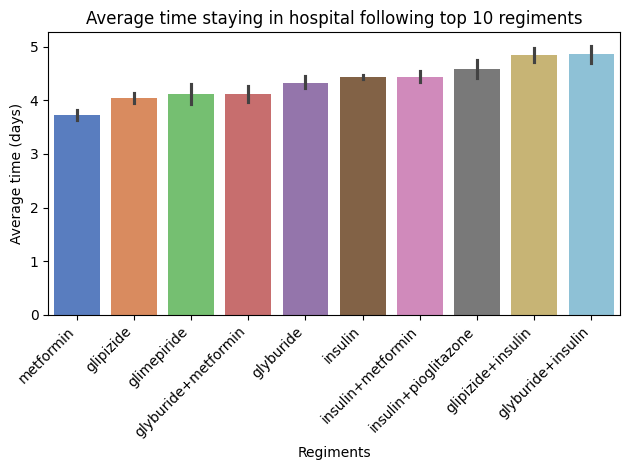

In [20]:
# Generate descriptive bar plot comparing mean days in hospital across the cohorts
sns.barplot(
    x = 'regiment',
    y = 'time_in_hospital',
    data = df_top_regiment,
    order = order,
    palette = 'muted'
)

# Render structural plot aesthetics and titles
plt.title('Average time staying in hospital following top 10 regiments')
plt.xlabel('Regiments')
plt.ylabel('Average time (days)')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

The bar chart displays the average hospital stay (in days) for the 10 most frequent diabetes medication regimens, sorted in ascending order of duration. The black error bars represent the 95% confidence intervals for each group.

| Medication Regimen | Approximate Mean Stay (Days) | Core Insight Grouping |
| :--- | :---: | :--- |
| **metformin** | ~3.8 | **Shortest Stay:** Confirms Metformin monotherapy as the most operationally efficient cohort. |
| **glipizide** | ~4.1 | **Oral Monotherapies:** Intermediate stay durations before insulin escalation. |
| **glimepiride** | ~4.2 | |
| **glyburide + metformin** | ~4.2 | |
| **glyburide** | ~4.4 | |
| **insulin** | ~4.5 | **The Insulin Threshold:** Regimens involving insulin shift the baseline stay to $\ge 4.5$ days. |
| **insulin + metformin** | ~4.5 | |
| **insulin + pioglitazone** | ~4.7 | |
| **glipizide + insulin** | ~4.8 | |
| **glyburide + insulin** | ~4.9 |  **Longest Stay:** Complex combination therapies involving both secretagogues and insulin.|

---

### Key Visual Takeaways:

1. **The Step-Up Complexity Trend:** There is a clear visual gradient showing that as a patient's regimen moves from single oral agents (`metformin`) to dual therapies, and finally to insulin-based combinations (`glyburide + insulin`), the average length of stay steadily climbs from under 4 days to a nearly 5 days.
2. **Visual Proof of the Tukey HSD Insights:**
   * **Metformin's** bar stands visibly shorter than all others, highlighting its statistical significance as the baseline with the lowest hospital footprint.
   * The final two bars (**glipizide+insulin**, **glyburide+insulin**) show nearly identical heights and highly overlapping error bars, visually demonstrating why the post-hoc test failed to reject the null hypothesis when comparing them against one another.